<a href="https://colab.research.google.com/github/Mohamed-Abdelaziz-Elsayed/Titanic-Dataset/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving test.csv to test (2).csv
Saving train.csv to train (5).csv


In [ ]:
df_train=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')

In [ ]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df_train.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [ ]:
def column_drop(dataframe,cat_th=3,car_th=50):

  cat_col=[col for col in dataframe.columns if dataframe[col].dtype=="O"]
  cat_but_car=[col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtype=="O"]

  num_but_cat=[col for col in dataframe.columns if dataframe[col].nunique() <= cat_th and dataframe[col].dtypes != "O"]

  cat_col = cat_col + num_but_cat
  cat_col=[col for col in cat_col if col not in cat_but_car]

  num_col=[col for col in dataframe.columns if dataframe[col].dtype!="O"]
  num_col=[col for col in num_col if col not in num_but_cat]

  print(f"Observations: {dataframe.shape[0]}")
  print(f"Variables: {dataframe.shape[1]}")
  print(f'cat_cols: {len(cat_col)}')
  print(f'num_cols: {len(num_col)}')
  print(f'cat_but_car: {len(cat_but_car)}')
  print(f'num_but_cat: {len(num_but_cat)}')
  return num_col,cat_col,cat_but_car


In [ ]:
num_cols,cat_cols,cat_car=column_drop(df_train)
num_cols_test,cat_cols_test,cat_car_test=column_drop(df_test)

Observations: 891
Variables: 12
cat_cols: 4
num_cols: 5
cat_but_car: 3
num_but_cat: 2
Observations: 418
Variables: 11
cat_cols: 3
num_cols: 5
cat_but_car: 3
num_but_cat: 1


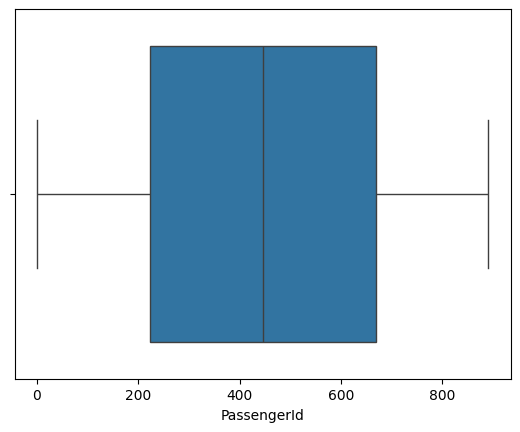

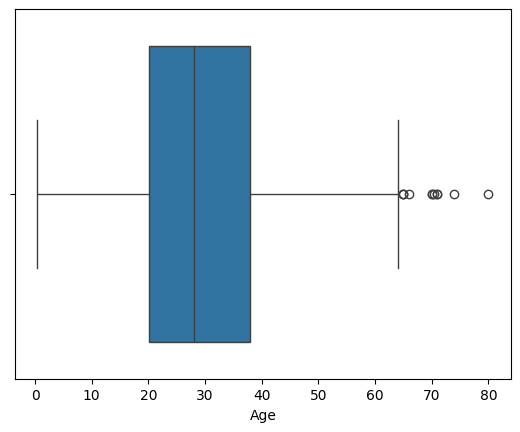

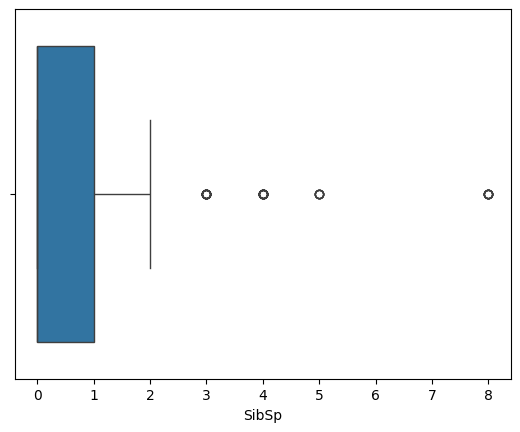

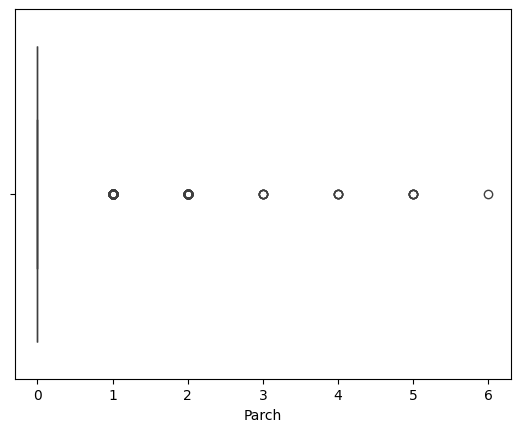

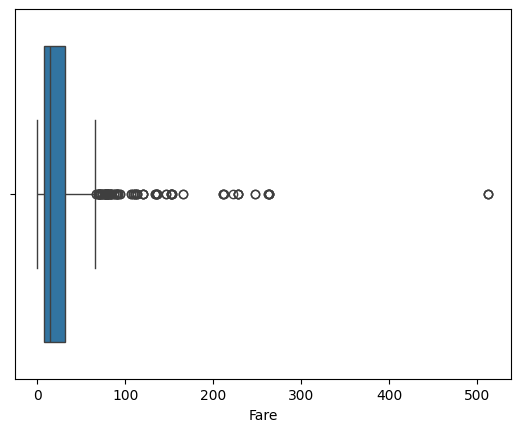

In [ ]:
for col in df_train[num_cols]:
    plt.figure()
    sns.boxplot(x=df_train[col])

In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
from numpy import percentile
def outlier_threshold (dataframe,col_name,q1=0.25,q3=0.75):
  q1_value,q3_value=dataframe[col_name].quantile([q1,q3])
  iqr=q3_value-q1_value
  return float(q1_value - 1.5 * iqr), float(q3_value + 1.5 * iqr)

In [ ]:
def outlier_replace (dataframe, col_name, q1=0.25,q3=0.75):
  lower,upper=outlier_threshold(dataframe,col_name,q1,q3)
  if lower == upper:  # degenerate case, skip
    print(f"Skipping {col_name} — IQR is zero")
    return
  dataframe.loc[dataframe[col_name] < float(lower), col_name] = lower
  dataframe.loc[dataframe[col_name] > float(upper), col_name] =  upper

In [ ]:
def check_oulier (dataframe,col_name):
  low_limit, up_limit = outlier_threshold(dataframe, col_name)
  if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
  else:
        return False

In [ ]:
for col in num_cols:
    print(check_oulier(df_train,col))

False
True
True
True
True


In [ ]:
for col in num_cols:
  outlier_replace(df_train,col)


Skipping Parch — IQR is zero


/tmp/ipykernel_74289/3999971013.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[col_name] < float(lower), col_name] = lower


In [ ]:
for col in num_cols_test:
  outlier_replace(df_test,col)


Skipping Parch — IQR is zero


/tmp/ipykernel_74289/3999971013.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '683.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[col_name] < float(lower), col_name] = lower
/tmp/ipykernel_74289/3999971013.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[col_name] < float(lower), col_name] = lower


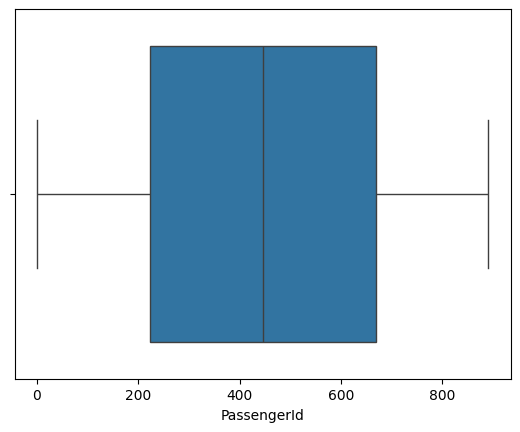

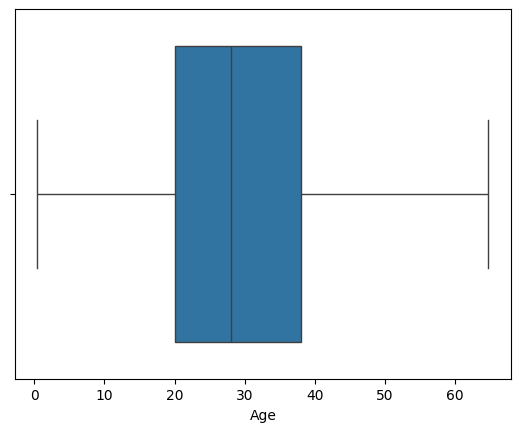

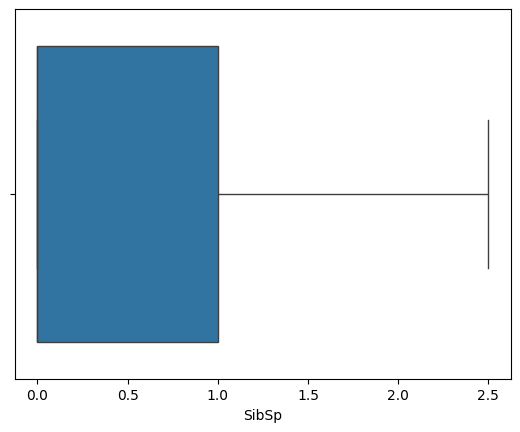

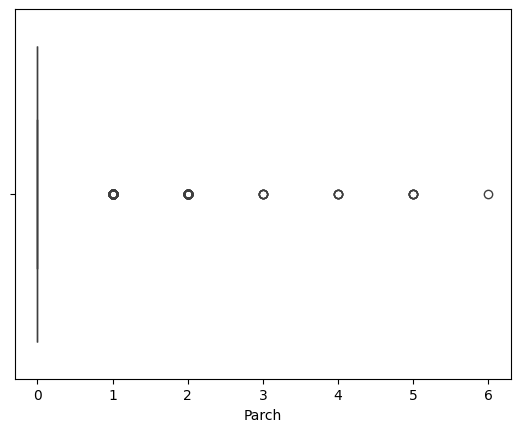

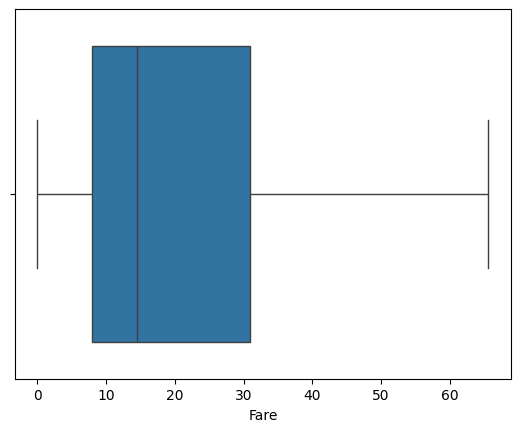

In [ ]:
for col in df_train[num_cols]:
    plt.figure()
    sns.boxplot(x=df_train[col])

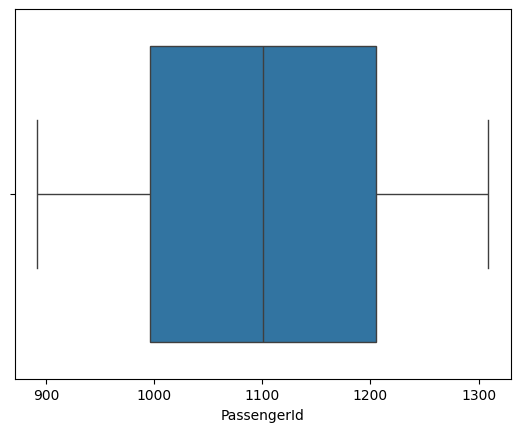

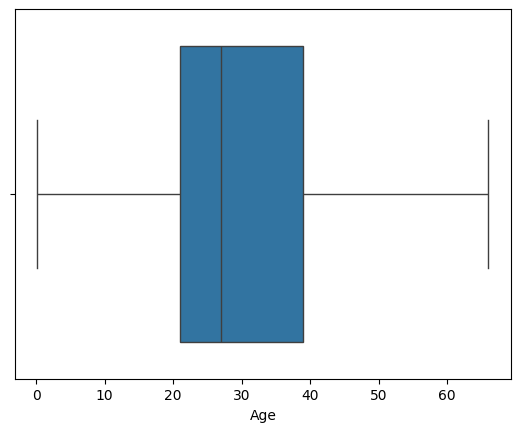

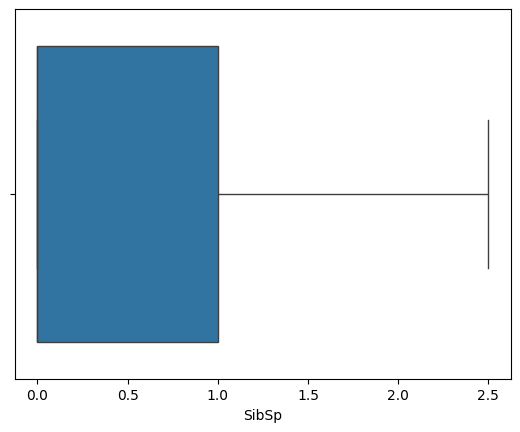

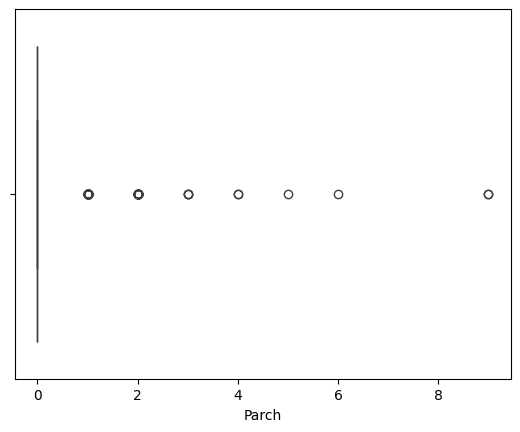

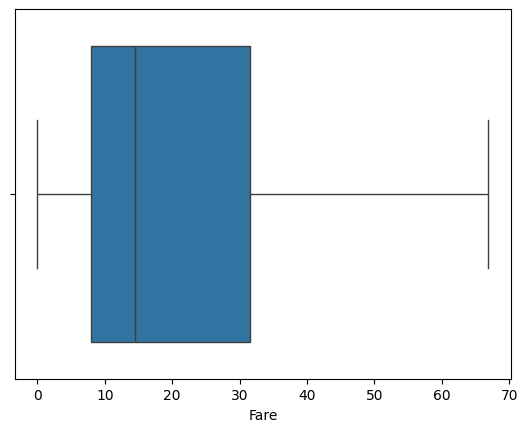

In [ ]:
for col in df_test[num_cols]:
    plt.figure()
    sns.boxplot(x=df_test[col])

In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df_train["Embarked"].fillna(df_train["Embarked"].mode()[0], inplace=True)
df_train["Age"].fillna(df_train["Age"].median(), inplace=True)
df_train.drop("Cabin", axis=1, inplace=True)


/tmp/ipykernel_74289/3394925996.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["Embarked"].fillna(df_train["Embarked"].mode()[0], inplace=True)
/tmp/ipykernel_74289/3394925996.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [ ]:
df_test["Embarked"].fillna(df_test["Embarked"].mode()[0], inplace=True)
df_test["Age"].fillna(df_train["Age"].median(), inplace=True)
df_test["Fare"].fillna(df_train["Age"].median(), inplace=True)
df_test["Age"].fillna(df_train["Age"].median(), inplace=True)


/tmp/ipykernel_74289/353003579.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test["Embarked"].fillna(df_test["Embarked"].mode()[0], inplace=True)
/tmp/ipykernel_74289/353003579.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df_test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,327


<Axes: >

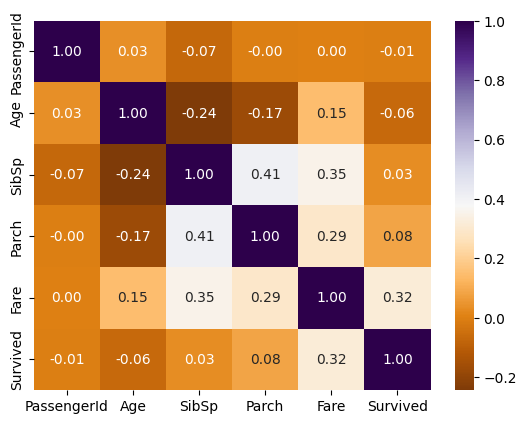

In [ ]:
num_and_target_columns = num_cols + ["Survived"]
corr_matrix = df_train[num_and_target_columns].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="PuOr")

In [ ]:
print(df_train["Parch"].value_counts())
print(df_train["Parch"].nunique())

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
7


In [ ]:
print(df_train["Parch"])


0      0
1      0
2      0
3      0
4      0
      ..
886    0
887    0
888    2
889    0
890    0
Name: Parch, Length: 891, dtype: int64


In [ ]:
df_train.drop("PassengerId", axis=1, inplace=True)
num_cols = [col for col in num_cols if col != "PassengerId"]

In [ ]:
df_train = pd.get_dummies(df_train, columns=["Sex", "Embarked"], drop_first=True)

In [ ]:
print(df_test.head)

<bound method NDFrame.head of      PassengerId  Pclass                                          Name  \
0          892.0       3                              Kelly, Mr. James   
1          893.0       3              Wilkes, Mrs. James (Ellen Needs)   
2          894.0       2                     Myles, Mr. Thomas Francis   
3          895.0       3                              Wirz, Mr. Albert   
4          896.0       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)   
..           ...     ...                                           ...   
413       1305.0       3                            Spector, Mr. Woolf   
414       1306.0       1                  Oliva y Ocana, Dona. Fermina   
415       1307.0       3                  Saether, Mr. Simon Sivertsen   
416       1308.0       3                           Ware, Mr. Frederick   
417       1309.0       3                      Peter, Master. Michael J   

        Sex   Age  SibSp  Parch              Ticket     Fare Cabin Embarked  
0  

In [ ]:
df_test = pd.get_dummies(df_test, columns=["Sex", "Embarked"], drop_first=True)

In [ ]:
print(df_train.head)

<bound method NDFrame.head of      Survived  Pclass                                               Name  \
0           0       3                            Braund, Mr. Owen Harris   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2           1       3                             Heikkinen, Miss. Laina   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4           0       3                           Allen, Mr. William Henry   
..        ...     ...                                                ...   
886         0       2                              Montvila, Rev. Juozas   
887         1       1                       Graham, Miss. Margaret Edith   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"   
889         1       1                              Behr, Mr. Karl Howell   
890         0       3                                Dooley, Mr. Patrick   

      Age  SibSp  Parch            Ticket     Fare  Sex_m

In [ ]:
print(df_test.head)

<bound method NDFrame.head of      PassengerId  Pclass                                          Name   Age  \
0          892.0       3                              Kelly, Mr. James  34.5   
1          893.0       3              Wilkes, Mrs. James (Ellen Needs)  47.0   
2          894.0       2                     Myles, Mr. Thomas Francis  62.0   
3          895.0       3                              Wirz, Mr. Albert  27.0   
4          896.0       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  22.0   
..           ...     ...                                           ...   ...   
413       1305.0       3                            Spector, Mr. Woolf  28.0   
414       1306.0       1                  Oliva y Ocana, Dona. Fermina  39.0   
415       1307.0       3                  Saether, Mr. Simon Sivertsen  38.5   
416       1308.0       3                           Ware, Mr. Frederick  28.0   
417       1309.0       3                      Peter, Master. Michael J  28.0   

     SibS

In [ ]:
df_train.drop(["Name", "Ticket"], axis=1, inplace=True)


In [ ]:
df_test.drop(["Name", "Ticket","Cabin"], axis=1, inplace=True)


In [ ]:
scaler = StandardScaler()
df_train[num_cols] = scaler.fit_transform(df_train[num_cols])
df_test[num_cols] = scaler.transform(df_test[num_cols])


In [ ]:
print(num_cols)


['Age', 'SibSp', 'Parch', 'Fare']


In [ ]:
X_train = df_train.drop("Survived", axis=1)
y_train = df_train["Survived"]

X_test = df_test

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_train)
print(accuracy_score(y_train, y_pred))
print(classification_report(y_train, y_pred))

0.7957351290684624
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       549
           1       0.75      0.71      0.73       342

    accuracy                           0.80       891
   macro avg       0.79      0.78      0.78       891
weighted avg       0.79      0.80      0.79       891



In [ ]:
scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring="accuracy")
print(f"CV mean: {scores.mean():.3f} (+/- {scores.std():.3f})")



CV mean: 0.788 (+/- 0.015)


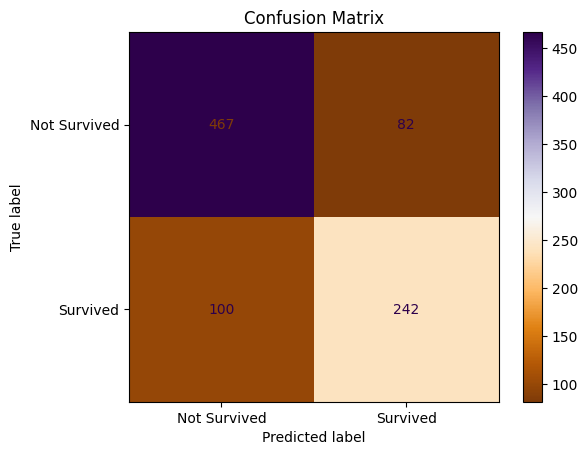

In [ ]:
cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived", "Survived"])
disp.plot(cmap="PuOr")
plt.title("Confusion Matrix")
plt.show()